## K-Means Clustering

### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

### Import dataset

In [3]:
df = pd.read_csv("cleaned_customer_financial_behaviour.csv")

### Select Features

In [4]:
features = [
    "annual_income",
    "monthly_income",
    "loan_amount",
    "credit_score_origination",
    "dti",
    "revolving_utilization_origination"
]

X = df[features]

### Standardise the data

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Elbow Mthode

In [6]:
sse = []
for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    sse.append(model.inertia_)

### Plot Elbow

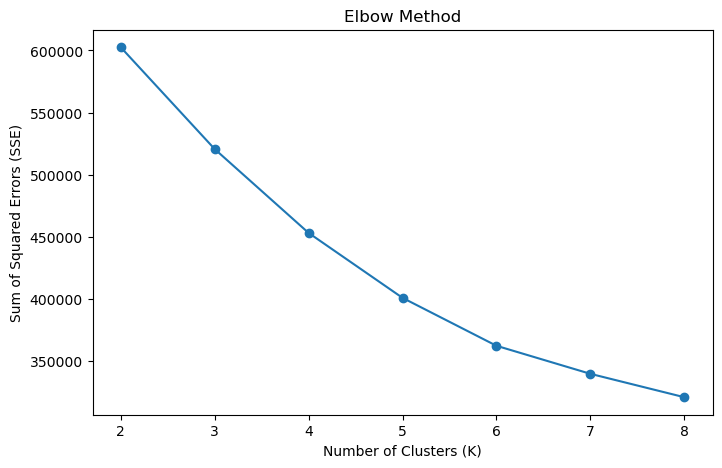

In [7]:
plt.figure(figsize=(8,5))
plt.plot(
    range(2,9),
    sse,
    marker="o"
)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.show()

### Train K-Means

In [8]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
df["cluster"] = kmeans.fit_predict(X_scaled)

### View Cluster Count

In [9]:
print(df["cluster"].value_counts())

cluster
2    74824
1    46316
0    13860
Name: count, dtype: int64


### Cluster Profile

In [10]:
cluster_profile = df.groupby("cluster")[features].mean()
print(cluster_profile)

         annual_income  monthly_income   loan_amount  \
cluster                                                
0        288699.173160    24058.264426  81500.105700   
1        110018.905735     9168.242144  50755.847698   
2        107404.974340     8950.414509  50638.840185   

         credit_score_origination       dti  revolving_utilization_origination  
cluster                                                                         
0                      689.996248  0.311014                           0.277736  
1                      690.273383  0.307198                           0.454027  
2                      689.957901  0.314450                           0.182052  


### Scatter Plot

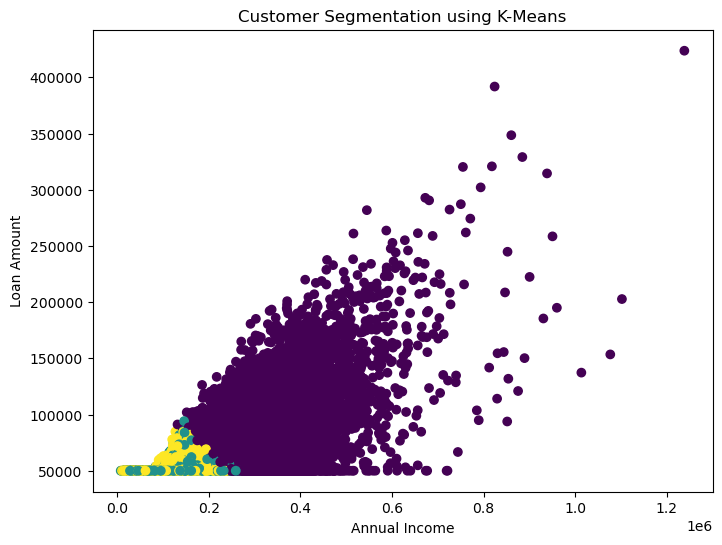

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["annual_income"],
    df["loan_amount"],
    c=df["cluster"]
)
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.title("Customer Segmentation using K-Means")
plt.show()